In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [4]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=45)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_7/2026-06-27_12-44-07_solo.json
Loading complete.
Pr

In [5]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [6]:
dropped_trials = 1
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 655
First trial end event found at index: 555
First trial end event found at index: 621
First trial end event found at index: 638
First trial end event found at index: 605
First trial end event found at index: 655
First trial end event found at index: 688
First trial end event found at index: 655
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at index: 671
First trial end event found at index: 605
First trial end event found at index: 2288
First trial end event found at index: 605
First trial end event found at index: 588
First trial end event found at index: 688
First trial end event found at index: 721
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 555
First trial end event found at index: 588
First trial end event found at index: 555
First trial end event found at index: 521
First trial end event found at in

In [7]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [8]:
import agent_analysis.functions.preprocessing as prep

_, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)
len(thetas)

No YAML file in excluded


45

In [69]:
def score_rate_player0_sessions(
    data_folder,
    json_filenames,
    time_unit="s",
    max_decision_duration=None
):
    """
    Player 0 score per unit time.

    Time is counted only between slice onset and trigger activation.
    Scores are summed across trial-end events.
    """

    score_rates = np.zeros(len(json_filenames))
    final_scores = np.zeros(len(json_filenames))

    for idx, json_filename in enumerate(json_filenames):
        print(data_folder + os.sep + json_filename)

        _, trials_list = prepare_data.prepare_data(data_folder, json_filename)

        total_score = 0
        total_time_seconds = 0

        for this_trial in trials_list:

            slice_onset_event = this_trial[
                this_trial["eventDescription"] == globals.SLICE_ONSET
            ]

            trigger_event = this_trial[
                this_trial["eventDescription"] == globals.SELECTED_TRIGGER_ACTIVATION
            ]

            trial_end = this_trial[
                this_trial["eventDescription"] == "trial end"
            ]

            if len(slice_onset_event) == 0:
                continue

            if len(trigger_event) == 0:
                continue

            if len(trial_end) == 0:
                continue

            slice_onset_idx = slice_onset_event.index[0]
            slice_onset_idx = int(slice_onset_idx - this_trial.index[0])

            trigger_idx = trigger_event.index[0]
            trigger_idx = int(trigger_idx - this_trial.index[0])

            decision_duration = (trigger_idx - slice_onset_idx) * 0.02

            if decision_duration < 0:
                continue

            if max_decision_duration is not None:
                if decision_duration > max_decision_duration:
                    continue

            trial_end_row = trial_end.iloc[-1]

            total_score = trial_end_row[
                globals.PLAYER_SCORE_DICT[0]["score"]
            ]

            final_scores[idx] = total_score

            total_time_seconds += decision_duration

        if time_unit == "min":
            total_time = total_time_seconds / 60
        elif time_unit == "s":
            total_time = total_time_seconds
        else:
            raise ValueError("time_unit must be 's' or 'min'")

        if total_time == 0:
            score_rates[idx] = np.nan
        else:
            if (total_score / total_time) > 50:
                print(f"Warning: Score rate exceeds 50 points per {time_unit} for file {json_filename}. Check data for anomalies.")
                print(f"Total score: {total_score}, Total time: {total_time} {time_unit}") 
            score_rates[idx] = total_score / total_time

    return score_rates, final_scores

In [73]:
score_rates, final_scores = score_rate_player0_sessions(
    data_folder,
    solo_files,
    time_unit="min",
    max_decision_duration=None
)

/Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
/Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
/Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
/Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
/Users/benny/swc/agents/data/split_cost_

In [78]:
log_ratios = []

for theta in (thetas):
    translation_cost, turning_cost = theta

    if translation_cost <= 0 or turning_cost <= 0:
        continue

    log_ratios.append(
        np.log2(translation_cost / turning_cost)
    )

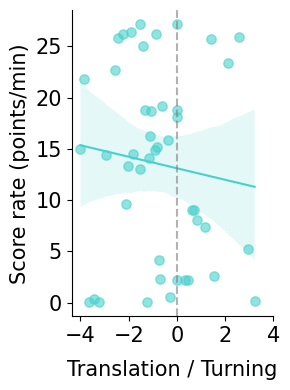

In [79]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.regplot(
    x=log_ratios,
    y=score_rates,
    scatter_kws={
        "color": "mediumturquoise",
        "s": 45,
        "alpha": 0.6
    },
    line_kws={
        "color": "mediumturquoise",
        "linewidth": 1.5
    },
    ci=95,
    ax=ax
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.set_xlabel(
    r"Translation / Turning",
    fontsize=15,
    labelpad=10
)
ax.set_ylabel(
    "Score rate (points/min)",
    fontsize=15,
)

ax.set_xticks(np.arange(-4, 4 + 0.1, 2))
#ax.set_yticks(np.arange(0, 30, 10))
#ax.set_ylim(0, 100)

ax.tick_params(labelsize=15)

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()

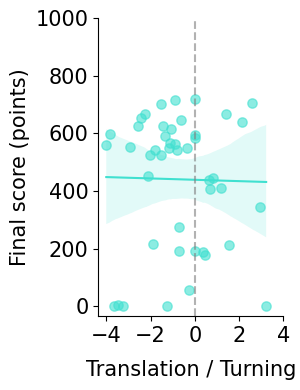

In [86]:
fig, ax = plt.subplots(figsize=(3.1, 4))

sns.regplot(
    x=log_ratios,
    y=final_scores,
    scatter_kws={
        "color": "turquoise",
        "s": 45,
        "alpha": 0.6
    },
    line_kws={
        "color": "turquoise",
        "linewidth": 1.5
    },
    ci=95,
    ax=ax
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.set_xlabel(
    r"Translation / Turning",
    fontsize=15,
    labelpad=10
)
ax.set_ylabel(
    "Final score (points)",
    fontsize=15,
)

ax.set_xticks(np.arange(-4, 4 + 0.1, 2))
ax.set_yticks(np.arange(0, 1001, 200))

ax.tick_params(labelsize=15)

sns.despine(ax=ax, top=True, right=True)
fig.tight_layout()
plt.show()